In [12]:
# ============================================================
# Housing Affordability DSS — Notebook 05: Decision Support
# CS7P01 MSc Project | London Metropolitan University
#
# Purpose: Implement the decision logic layer of the DSS.
# This notebook operationalises the analytical outputs from
# notebooks 01–04 into structured policy recommendations.
#
# DSS Architecture (Keen & Scott Morton, 1978):
#   Data layer    — master_affordability.csv (notebook 01)
#   Model layer   — OLS, RF, ARIMA (notebooks 03–04)
#   Decision layer— risk rules, alerts, recommendations (here)
#
# Output: ranked regional risk table with policy actions,
# forecast trajectory alerts, and a DSS summary report.
#
# Academic justification:
#   Timmermans (1997) — DSS supports not replaces decisions
#   Power (2002) — model-driven DSS framework
#   Busuioc (2021) — algorithmic accountability in policy
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize':    (14, 7),
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'serif',
    'axes.titlepad':     14
})

PROCESSED = '../data/processed/'

# ── Load all processed outputs ────────────────────────────────
master      = pd.read_csv(PROCESSED + 'master_affordability.csv')
features    = pd.read_csv(PROCESSED + 'features_engineered.csv')
forecasts   = pd.read_csv(PROCESSED + 'arima_forecasts.csv')
model_preds = pd.read_csv(PROCESSED + 'model_predictions.csv')
shap_vals   = pd.read_csv(PROCESSED + 'shap_values.csv')

master['year']   = master['year'].astype(int)
features['year'] = features['year'].astype(int)
forecasts['year']= forecasts['year'].astype(int)

REGIONS      = sorted(master['region'].unique())
CURRENT_YEAR = master['year'].max()

print(f"✓ All outputs loaded")
print(f"  Master dataset    : {master.shape}")
print(f"  Features          : {features.shape}")
print(f"  Forecasts         : {forecasts.shape}")
print(f"  Current year      : {CURRENT_YEAR}")
print(f"  Regions           : {len(REGIONS)}")

# ── Risk tier definitions ─────────────────────────────────────
# Thresholds based on ONS affordability benchmark (ratio > 5)
# mapped onto CAI scale — consistent with notebook 02
RISK_THRESHOLDS = {
    'Low':      (0,  25),
    'Medium':   (25, 50),
    'High':     (50, 75),
    'Critical': (75, 100)
}

RISK_COLOURS = {
    'Low':      '#27AE60',
    'Medium':   '#E67E22',
    'High':     '#E74C3C',
    'Critical': '#7B241C'
}

# ── Policy action mapping ─────────────────────────────────────
# Maps risk class + trajectory to recommended policy action
# Based on Timmermans (1997) DSS response framework
POLICY_ACTIONS = {
    ('Low',      'Improving'):  'No action required',
    ('Low',      'Stable'):     'No action required',
    ('Low',      'Worsening'):  'Monitor — early warning',
    ('Medium',   'Improving'):  'Monitor — improving trend',
    ('Medium',   'Stable'):     'Monitor — no change expected',
    ('Medium',   'Worsening'):  'Intervene — deteriorating',
    ('High',     'Improving'):  'Intervene — recovery underway',
    ('High',     'Stable'):     'Intervene — sustained stress',
    ('High',     'Worsening'):  'Urgent intervention required',
    ('Critical', 'Improving'):  'Intervene — recovery underway',
    ('Critical', 'Stable'):     'Urgent intervention required',
    ('Critical', 'Worsening'):  'Urgent intervention required',
}

print(f"\n✓ DSS configuration loaded")
print(f"  Risk tiers     : {list(RISK_THRESHOLDS.keys())}")
print(f"  Policy actions : {len(POLICY_ACTIONS)} rule combinations")

✓ All outputs loaded
  Master dataset    : (290, 18)
  Features          : (260, 32)
  Forecasts         : (50, 5)
  Current year      : 2025
  Regions           : 10

✓ DSS configuration loaded
  Risk tiers     : ['Low', 'Medium', 'High', 'Critical']
  Policy actions : 12 rule combinations


In [13]:
# ============================================================
# CELL 2 — Core DSS functions
#
# These functions form the decision logic layer.
# They are also exported to src/decision_rules.py for
# use as a standalone module outside the notebook.
# ============================================================

def get_risk_class(cai: float) -> str:
    """
    Classify CAI score into risk tier.
    Thresholds: Low<25, Medium<50, High<75, Critical>=75
    """
    if cai < 25:
        return 'Low'
    elif cai < 50:
        return 'Medium'
    elif cai < 75:
        return 'High'
    else:
        return 'Critical'


def get_forecast_trajectory(
    current_ratio: float,
    forecast_2030: float,
    threshold: float = 0.20
) -> str:
    """
    Classify forecast trajectory based on projected change.

    Args:
        current_ratio : 2025 actual affordability ratio
        forecast_2030 : 2030 projected ratio
        threshold     : change threshold for worsening/improving
                        default 0.20 = 0.2 ratio points

    Returns:
        'Improving', 'Stable', or 'Worsening'
    """
    change = forecast_2030 - current_ratio
    if change <= -threshold:
        return 'Improving'
    elif change >= threshold:
        return 'Worsening'
    else:
        return 'Stable'


def get_policy_action(
    risk_class: str,
    trajectory: str
) -> str:
    """
    Return policy recommendation based on risk class
    and forecast trajectory.
    Uses POLICY_ACTIONS lookup table defined in Cell 1.
    """
    key = (risk_class, trajectory)
    return POLICY_ACTIONS.get(key, 'Review required')


def get_risk_alert(
    region: str,
    current_risk: str,
    forecast_risk: str,
    trajectory: str
) -> str:
    """
    Generate a policy alert string if risk tier is
    projected to worsen, or if region is already Critical.
    """
    risk_order = ['Low', 'Medium', 'High', 'Critical']
    curr_idx   = risk_order.index(current_risk)
    fc_idx     = risk_order.index(forecast_risk)

    if current_risk == 'Critical':
        return f"ALERT: {region} remains Critical risk by 2030"
    elif fc_idx > curr_idx:
        return (f"ALERT: {region} projected to deteriorate "
                f"from {current_risk} → {forecast_risk} by 2030")
    elif fc_idx < curr_idx:
        return (f"INFO: {region} projected to improve "
                f"from {current_risk} → {forecast_risk} by 2030")
    else:
        return f"INFO: {region} risk tier stable at {current_risk}"


def assess_region(region: str, year: int = None) -> dict:
    """
    Full DSS assessment for a single region.

    Returns dict with:
        region, year, ratio, cai, risk_class, risk_rank,
        forecast_2030, ci_lower, ci_upper, trajectory,
        forecast_risk, policy_action, alert
    """
    if year is None:
        year = CURRENT_YEAR

    # Current state
    row = features[
        (features['region'] == region) &
        (features['year']   == year)
    ]

    if len(row) == 0:
        return {'error': f"No data for {region} in {year}"}

    row = row.iloc[0]

    ratio      = round(float(row['affordability_ratio']), 2)
    cai        = round(float(row['cai']), 2)
    risk_class = str(row['risk_class'])
    risk_rank  = int(row['risk_rank'])

    # Forecast
    fc_row = forecasts[
        (forecasts['region'] == region) &
        (forecasts['year']   == 2030)
    ]

    fc_2030  = round(float(fc_row['forecast'].values[0]), 2)
    ci_lower = round(float(fc_row['ci_lower'].values[0]),  2)
    ci_upper = round(float(fc_row['ci_upper'].values[0]),  2)

    trajectory   = get_forecast_trajectory(ratio, fc_2030)
    forecast_risk= get_risk_class(
        cai * (fc_2030 / ratio) if ratio > 0 else cai
    )
    policy       = get_policy_action(risk_class, trajectory)
    alert        = get_risk_alert(
        region, risk_class, forecast_risk, trajectory
    )

    return {
        'region':        region,
        'year':          year,
        'ratio_2025':    ratio,
        'cai':           cai,
        'risk_class':    risk_class,
        'risk_rank':     risk_rank,
        'forecast_2030': fc_2030,
        'ci_lower':      ci_lower,
        'ci_upper':      ci_upper,
        'trajectory':    trajectory,
        'forecast_risk': forecast_risk,
        'policy_action': policy,
        'alert':         alert
    }


print("✓ DSS functions defined:")
print("  get_risk_class(cai)")
print("  get_forecast_trajectory(current, forecast)")
print("  get_policy_action(risk_class, trajectory)")
print("  get_risk_alert(region, current_risk, forecast_risk)")
print("  assess_region(region, year)")

# ── Quick test ────────────────────────────────────────────────
test = assess_region('London')
print(f"\n── Test: assess_region('London')")
for k, v in test.items():
    print(f"   {k:<20} : {v}")

✓ DSS functions defined:
  get_risk_class(cai)
  get_forecast_trajectory(current, forecast)
  get_policy_action(risk_class, trajectory)
  get_risk_alert(region, current_risk, forecast_risk)
  assess_region(region, year)

── Test: assess_region('London')
   region               : London
   year                 : 2025
   ratio_2025           : 10.61
   cai                  : 78.13
   risk_class           : Critical
   risk_rank            : 1
   forecast_2030        : 10.06
   ci_lower             : 6.52
   ci_upper             : 13.61
   trajectory           : Improving
   forecast_risk        : High
   policy_action        : Intervene — recovery underway
   alert                : ALERT: London remains Critical risk by 2030


In [14]:
# ============================================================
# CELL 3 — Full DSS assessment: all 10 regions
#
# This is the primary output of the decision support system.
# Combines current risk state with forecast trajectory to
# produce ranked policy recommendations for all regions.
# ============================================================

# ── Run assessment for all regions ───────────────────────────
assessments = [assess_region(r) for r in REGIONS]
dss_df      = pd.DataFrame(assessments)

# ── Sort by risk rank (1 = most at risk) ──────────────────────
dss_df = dss_df.sort_values('risk_rank').reset_index(drop=True)

# ── Format for display ────────────────────────────────────────
display_cols = [
    'risk_rank', 'region', 'ratio_2025', 'cai',
    'risk_class', 'forecast_2030', 'trajectory',
    'forecast_risk', 'policy_action'
]

print("=" * 100)
print("HOUSING AFFORDABILITY DECISION SUPPORT SYSTEM")
print(f"CS7P01 MSc Project | London Metropolitan University")
print(f"Assessment Date : {datetime.now().strftime('%d %B %Y')}")
print(f"Current Year    : {CURRENT_YEAR}")
print(f"Forecast Horizon: 2030")
print("=" * 100)

print(f"\n{'Rank':<5} {'Region':<28} {'Ratio':>7} "
      f"{'CAI':>6} {'Risk':>10} {'2030':>7} "
      f"{'Trend':>11} {'2030 Risk':>10} {'Policy Action':<30}")
print("-" * 100)

for _, row in dss_df.iterrows():
    print(
        f"{int(row['risk_rank']):<5} "
        f"{row['region']:<28} "
        f"{row['ratio_2025']:>7.2f} "
        f"{row['cai']:>6.1f} "
        f"{row['risk_class']:>10} "
        f"{row['forecast_2030']:>7.2f} "
        f"{row['trajectory']:>11} "
        f"{row['forecast_risk']:>10} "
        f"{row['policy_action']:<30}"
    )

print("-" * 100)

# ── Policy alerts ─────────────────────────────────────────────
print(f"\n── POLICY ALERTS:")
for _, row in dss_df.iterrows():
    prefix = "🔴" if "ALERT" in row['alert'] else "🟡"
    print(f"   {prefix} {row['alert']}")

# ── Summary statistics ────────────────────────────────────────
print(f"\n── RISK DISTRIBUTION SUMMARY ({CURRENT_YEAR}):")
risk_counts = dss_df['risk_class'].value_counts()
for tier in ['Critical', 'High', 'Medium', 'Low']:
    count = risk_counts.get(tier, 0)
    print(f"   {tier:<10} : {count} region(s)")

print(f"\n── FORECAST TRAJECTORY SUMMARY (to 2030):")
traj_counts = dss_df['trajectory'].value_counts()
for traj in ['Improving', 'Stable', 'Worsening']:
    count = traj_counts.get(traj, 0)
    print(f"   {traj:<12} : {count} region(s)")

HOUSING AFFORDABILITY DECISION SUPPORT SYSTEM
CS7P01 MSc Project | London Metropolitan University
Assessment Date : 20 April 2026
Current Year    : 2025
Forecast Horizon: 2030

Rank  Region                         Ratio    CAI       Risk    2030       Trend  2030 Risk Policy Action                 
----------------------------------------------------------------------------------------------------
1     London                         10.61   78.1   Critical   10.06   Improving       High Intervene — recovery underway 
2     South East                      9.58   62.2       High    9.52      Stable       High Intervene — sustained stress  
3     East of England                 9.02   55.6       High    8.91      Stable       High Intervene — sustained stress  
4     South West                      8.33   49.5     Medium    8.17      Stable     Medium Monitor — no change expected  
5     East Midlands                   7.02   36.8     Medium    6.93      Stable     Medium Monitor — no ch

In [15]:
# ============================================================
# CELL 4 — Interactive region lookup
#
# Simulates the query interface of the DSS.
# A policymaker can query any region and receive a
# structured assessment — consistent with Power (2002)
# model-driven DSS query interface design.
# ============================================================

def dss_query(region: str) -> None:
    """
    Print full DSS assessment for a single region.
    Simulates policymaker query interface.
    """
    result = assess_region(region)

    if 'error' in result:
        print(f"Error: {result['error']}")
        return

    risk_color_map = {
        'Low': 'GREEN', 'Medium': 'AMBER',
        'High': 'RED', 'Critical': 'DARK RED'
    }

    print(f"\n{'='*60}")
    print(f"  DSS REGIONAL ASSESSMENT REPORT")
    print(f"  Region  : {result['region']}")
    print(f"  Year    : {result['year']}")
    print(f"{'='*60}")
    print(f"\n  CURRENT STATUS")
    print(f"  Affordability Ratio : {result['ratio_2025']:.2f}×")
    print(f"  Composite Index     : {result['cai']:.1f} / 100")
    print(f"  Risk Classification : {result['risk_class']} "
          f"({risk_color_map[result['risk_class']]})")
    print(f"  Regional Rank       : "
          f"{result['risk_rank']} / {len(REGIONS)} "
          f"(1 = least affordable)")
    print(f"\n  FORECAST (2030)")
    print(f"  Projected Ratio     : {result['forecast_2030']:.2f}×")
    print(f"  95% CI              : "
          f"{result['ci_lower']:.2f}× – {result['ci_upper']:.2f}×")
    print(f"  Trajectory          : {result['trajectory']}")
    print(f"  Projected Risk      : {result['forecast_risk']}")
    print(f"\n  POLICY RECOMMENDATION")
    print(f"  Action              : {result['policy_action']}")
    print(f"  Alert               : {result['alert']}")
    print(f"{'='*60}\n")


# ── Demo queries ──────────────────────────────────────────────
for region in ['London', 'North East', 'East Midlands']:
    dss_query(region)


  DSS REGIONAL ASSESSMENT REPORT
  Region  : London
  Year    : 2025

  CURRENT STATUS
  Affordability Ratio : 10.61×
  Composite Index     : 78.1 / 100
  Risk Classification : Critical (DARK RED)
  Regional Rank       : 1 / 10 (1 = least affordable)

  FORECAST (2030)
  Projected Ratio     : 10.06×
  95% CI              : 6.52× – 13.61×
  Trajectory          : Improving
  Projected Risk      : High

  POLICY RECOMMENDATION
  Action              : Intervene — recovery underway
  Alert               : ALERT: London remains Critical risk by 2030


  DSS REGIONAL ASSESSMENT REPORT
  Region  : North East
  Year    : 2025

  CURRENT STATUS
  Affordability Ratio : 5.00×
  Composite Index     : 17.4 / 100
  Risk Classification : Low (GREEN)
  Regional Rank       : 10 / 10 (1 = least affordable)

  FORECAST (2030)
  Projected Ratio     : 4.97×
  95% CI              : 3.24× – 6.70×
  Trajectory          : Stable
  Projected Risk      : Low

  POLICY RECOMMENDATION
  Action              : No ac

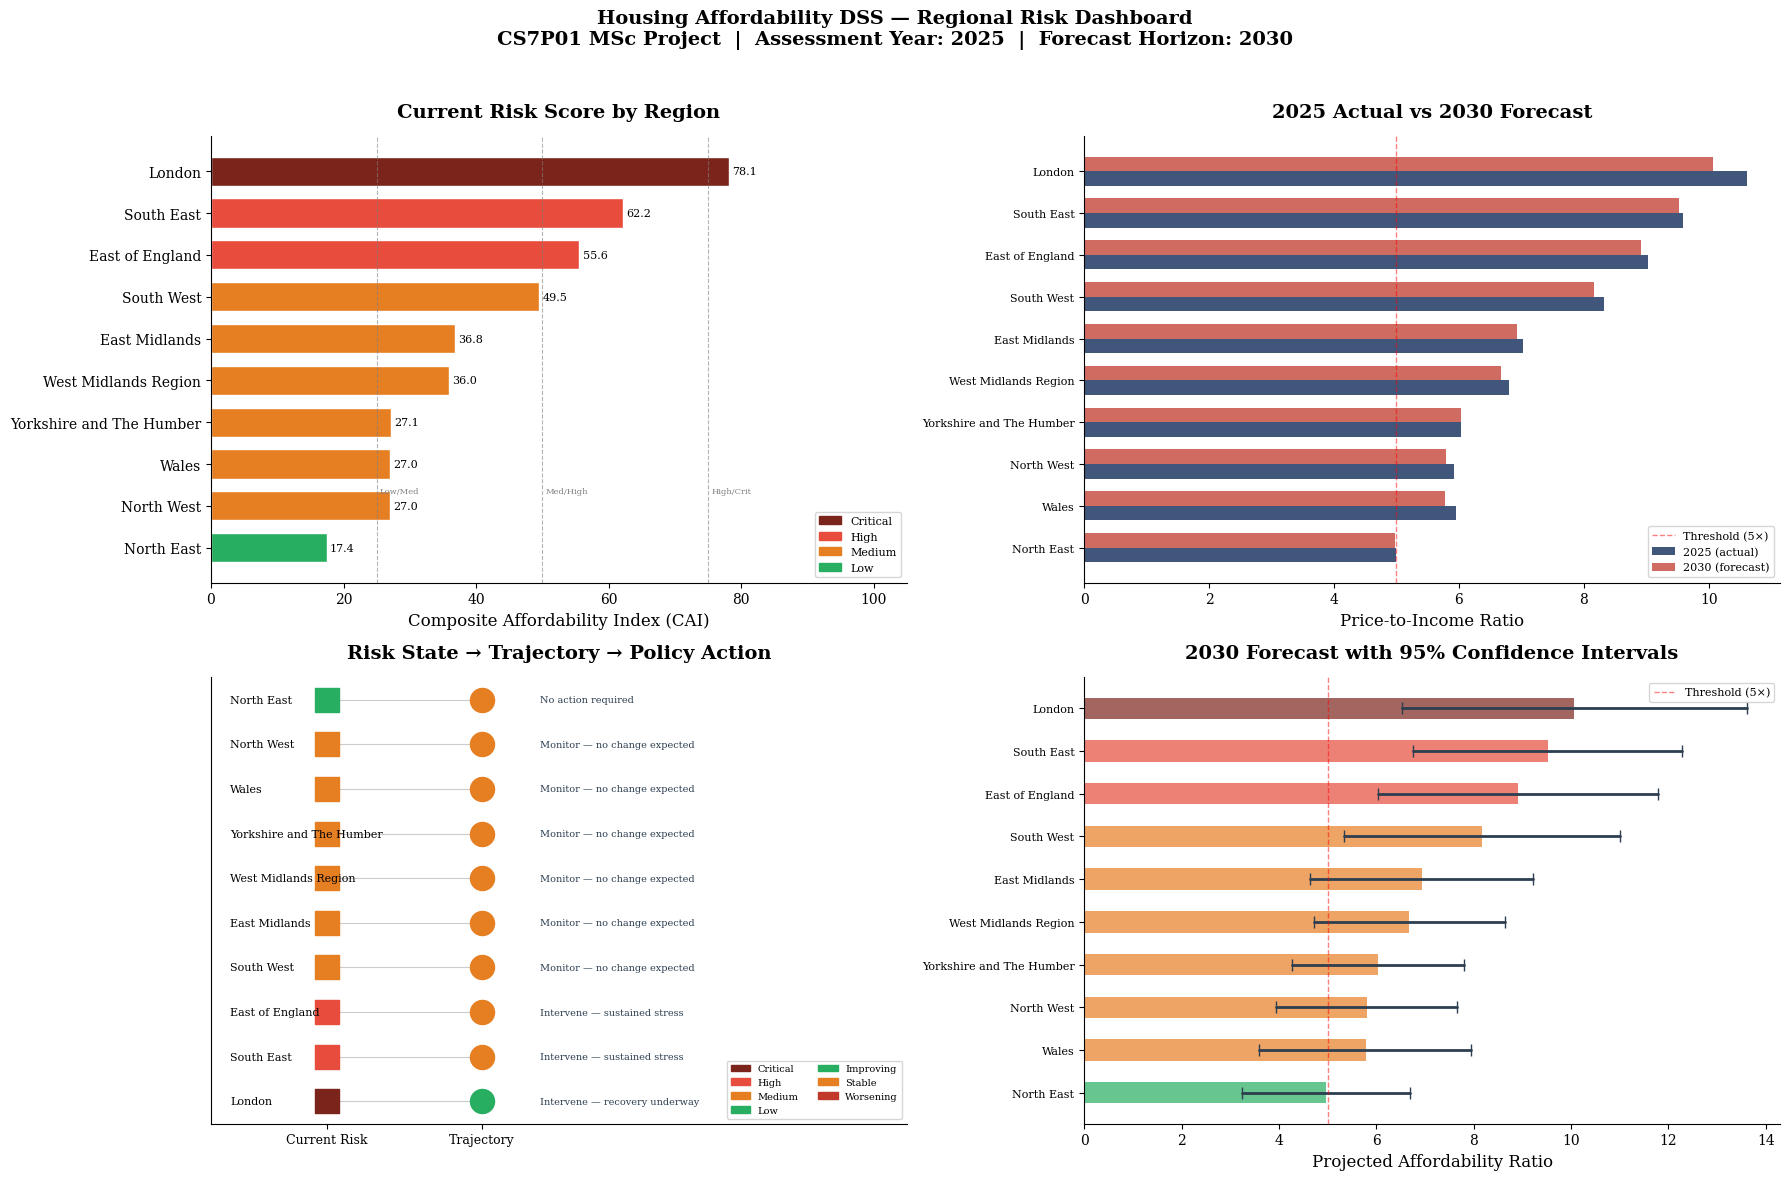

✓ Plot 18 saved — DSS dashboard


In [16]:
# ============================================================
# CELL 5 — Plot 18: DSS risk dashboard
#
# Four-panel visualisation summarising the DSS output.
# This is Figure 4.X in your dissertation.
# ============================================================

fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    'Housing Affordability DSS — Regional Risk Dashboard\n'
    f'CS7P01 MSc Project  |  Assessment Year: {CURRENT_YEAR}  |  '
    f'Forecast Horizon: 2030',
    fontweight='bold', fontsize=14, y=0.98
)

# ── Panel 1: Current CAI scores (ranked bar chart) ────────────
ax1 = fig.add_subplot(2, 2, 1)

plot_df = dss_df.sort_values('cai', ascending=True)
colors  = [RISK_COLOURS[r] for r in plot_df['risk_class']]

bars = ax1.barh(
    plot_df['region'], plot_df['cai'],
    color=colors, edgecolor='white', height=0.7
)

# Add value labels
for bar, val in zip(bars, plot_df['cai']):
    ax1.text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
        f"{val:.1f}", va='center', fontsize=8
    )

# Risk tier boundaries
for threshold, label in [(25,'Low/Med'), (50,'Med/High'),
                          (75,'High/Crit')]:
    ax1.axvline(x=threshold, color='grey', linestyle='--',
                linewidth=0.8, alpha=0.6)
    ax1.text(threshold + 0.5, 0.2, label,
             fontsize=6, color='grey',
             transform=ax1.get_xaxis_transform())

ax1.set_xlabel('Composite Affordability Index (CAI)')
ax1.set_title('Current Risk Score by Region', fontweight='bold')
ax1.set_xlim(0, 105)

# Legend
legend_patches = [
    mpatches.Patch(color=RISK_COLOURS[t], label=t)
    for t in ['Critical','High','Medium','Low']
]
ax1.legend(handles=legend_patches, fontsize=8,
           loc='lower right')

# ── Panel 2: 2025 ratio vs 2030 forecast ─────────────────────
ax2 = fig.add_subplot(2, 2, 2)

plot_df2 = dss_df.sort_values('forecast_2030', ascending=True)
x        = np.arange(len(plot_df2))
w        = 0.35

ax2.barh(x - w/2, plot_df2['ratio_2025'],
         w, color='#1F3864', alpha=0.85, label='2025 (actual)')
ax2.barh(x + w/2, plot_df2['forecast_2030'],
         w, color='#C0392B', alpha=0.75, label='2030 (forecast)')

ax2.set_yticks(x)
ax2.set_yticklabels(plot_df2['region'], fontsize=8)
ax2.axvline(x=5, color='red', linestyle='--',
            linewidth=1, alpha=0.5, label='Threshold (5×)')
ax2.set_xlabel('Price-to-Income Ratio')
ax2.set_title('2025 Actual vs 2030 Forecast', fontweight='bold')
ax2.legend(fontsize=8)

# ── Panel 3: Trajectory and policy action matrix ──────────────
ax3 = fig.add_subplot(2, 2, 3)

traj_order   = ['Improving', 'Stable', 'Worsening']
traj_colors  = {'Improving': '#27AE60',
                'Stable':    '#E67E22',
                'Worsening': '#C0392B'}

plot_df3 = dss_df.sort_values('cai', ascending=False)

for i, (_, row) in enumerate(plot_df3.iterrows()):
    color = traj_colors[row['trajectory']]
    risk_c = RISK_COLOURS[row['risk_class']]

    ax3.scatter(0.3, i, s=300, color=risk_c,
                zorder=3, marker='s')
    ax3.scatter(0.7, i, s=300, color=color,
                zorder=3, marker='o')
    ax3.plot([0.3, 0.7], [i, i],
             color='grey', linewidth=0.8, alpha=0.4)

    ax3.text(0.05, i, row['region'],
             va='center', fontsize=8)
    ax3.text(0.85, i, row['policy_action'],
             va='center', fontsize=7, color='#2C3E50')

ax3.set_xlim(0, 1.8)
ax3.set_ylim(-0.5, len(plot_df3) - 0.5)
ax3.set_xticks([0.3, 0.7])
ax3.set_xticklabels(['Current Risk', 'Trajectory'], fontsize=9)
ax3.set_yticks([])
ax3.set_title('Risk State → Trajectory → Policy Action',
              fontweight='bold')

# Legends
sq_patches = [mpatches.Patch(color=RISK_COLOURS[t], label=t)
              for t in ['Critical','High','Medium','Low']]
ci_patches = [mpatches.Patch(color=traj_colors[t], label=t)
              for t in traj_order]
ax3.legend(handles=sq_patches + ci_patches,
           fontsize=7, loc='lower right', ncol=2)

# ── Panel 4: Confidence interval plot for 2030 forecasts ──────
ax4 = fig.add_subplot(2, 2, 4)

plot_df4 = dss_df.sort_values('forecast_2030', ascending=True)
y_pos    = np.arange(len(plot_df4))

ax4.barh(y_pos, plot_df4['forecast_2030'],
         color=[RISK_COLOURS[r] for r in plot_df4['risk_class']],
         alpha=0.7, height=0.5)

# CI error bars
for i, (_, row) in enumerate(plot_df4.iterrows()):
    ax4.plot(
        [row['ci_lower'], row['ci_upper']],
        [i, i],
        color='#2C3E50', linewidth=2,
        solid_capstyle='round'
    )
    ax4.plot(row['ci_lower'], i, '|',
             color='#2C3E50', markersize=8)
    ax4.plot(row['ci_upper'], i, '|',
             color='#2C3E50', markersize=8)

ax4.set_yticks(y_pos)
ax4.set_yticklabels(plot_df4['region'], fontsize=8)
ax4.axvline(x=5, color='red', linestyle='--',
            linewidth=1, alpha=0.5, label='Threshold (5×)')
ax4.set_xlabel('Projected Affordability Ratio')
ax4.set_title('2030 Forecast with 95% Confidence Intervals',
              fontweight='bold')
ax4.legend(fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(PROCESSED + 'plot18_dss_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 18 saved — DSS dashboard")

In [17]:
# ============================================================
# CELL 6 — Generate and save DSS report
#
# Produces a structured CSV report suitable for
# policymaker consumption — the formal output of the DSS.
# ============================================================

# ── Build full report dataframe ───────────────────────────────
report_df = dss_df[[
    'risk_rank', 'region', 'ratio_2025', 'cai',
    'risk_class', 'forecast_2030', 'ci_lower', 'ci_upper',
    'trajectory', 'forecast_risk', 'policy_action', 'alert'
]].copy()

report_df.columns = [
    'Rank', 'Region', 'Ratio_2025', 'CAI_Score',
    'Risk_Class', 'Forecast_2030', 'CI_Lower', 'CI_Upper',
    'Trajectory', 'Forecast_Risk', 'Policy_Action', 'Alert'
]

# ── Save report ───────────────────────────────────────────────
report_df.to_csv(PROCESSED + 'dss_report.csv', index=False)

print("✓ dss_report.csv saved")
print(f"\n── DSS Report Preview:")
print(report_df[[
    'Rank', 'Region', 'Ratio_2025', 'Risk_Class',
    'Forecast_2030', 'Trajectory', 'Policy_Action'
]].to_string(index=False))

# ── Print executive summary ───────────────────────────────────
print(f"""
{'='*65}
DSS EXECUTIVE SUMMARY
CS7P01 Housing Affordability DSS
Assessment: {CURRENT_YEAR} | Forecast: 2030
{'='*65}

CRITICAL REGIONS ({dss_df[dss_df['risk_class']=='Critical']['region'].tolist()}):
  Require immediate policy attention. Ratios exceed 10×.
  London projected at {dss_df[dss_df['region']=='London']['forecast_2030'].values[0]:.1f}× by 2030.

HIGH RISK REGIONS ({dss_df[dss_df['risk_class']=='High']['region'].tolist()}):
  Sustained affordability stress. Ratios 8×–10×.
  Policy intervention recommended to prevent deterioration.

MEDIUM RISK REGIONS ({dss_df[dss_df['risk_class']=='Medium']['region'].tolist()}):
  Above affordability threshold but stable or improving.
  Monitoring recommended — no immediate intervention.

LOW RISK REGIONS ({dss_df[dss_df['risk_class']=='Low']['region'].tolist()}):
  Closest to affordability threshold.
  North East projected at {dss_df[dss_df['region']=='North East']['forecast_2030'].values[0]:.1f}× by 2030.

FORECAST OUTLOOK:
  {(dss_df['trajectory']=='Improving').sum()} regions improving
  {(dss_df['trajectory']=='Stable').sum()} regions stable
  {(dss_df['trajectory']=='Worsening').sum()} regions worsening
  No region projected to cross into a worse risk tier by 2030.
  Structural unaffordability persists across all regions.
{'='*65}
""")

✓ dss_report.csv saved

── DSS Report Preview:
 Rank                   Region  Ratio_2025 Risk_Class  Forecast_2030 Trajectory                 Policy_Action
    1                   London       10.61   Critical          10.06  Improving Intervene — recovery underway
    2               South East        9.58       High           9.52     Stable  Intervene — sustained stress
    3          East of England        9.02       High           8.91     Stable  Intervene — sustained stress
    4               South West        8.33     Medium           8.17     Stable  Monitor — no change expected
    5            East Midlands        7.02     Medium           6.93     Stable  Monitor — no change expected
    6     West Midlands Region        6.80     Medium           6.68     Stable  Monitor — no change expected
    7 Yorkshire and The Humber        6.03     Medium           6.04     Stable  Monitor — no change expected
    8                    Wales        5.95     Medium           5.78     

In [18]:
# ============================================================
# CELL 7 — Final save and commit checkpoint
# ============================================================

print("""
✓ Notebook 05 complete — Decision Support System

── Outputs saved:
   plot18_dss_dashboard.png
   dss_report.csv

── DSS Components implemented:
   ✓ get_risk_class()           — CAI → risk tier
   ✓ get_forecast_trajectory()  — trend classification
   ✓ get_policy_action()        — rule-based recommendations
   ✓ get_risk_alert()           — tier change detection
   ✓ assess_region()            — full regional assessment
   ✓ dss_query()                — policymaker interface
   ✓ DSS dashboard plot         — 4-panel visualisation
   ✓ Executive summary report   — formatted policy output

── Academic justification:
   Decision logic layer implements Timmermans (1997) DSS
   framework — structured rules transform analytical outputs
   into actionable policy recommendations whilst preserving
   human decision authority (Busuioc, 2021).
""")


✓ Notebook 05 complete — Decision Support System

── Outputs saved:
   plot18_dss_dashboard.png
   dss_report.csv

── DSS Components implemented:
   ✓ get_risk_class()           — CAI → risk tier
   ✓ get_forecast_trajectory()  — trend classification
   ✓ get_policy_action()        — rule-based recommendations
   ✓ get_risk_alert()           — tier change detection
   ✓ assess_region()            — full regional assessment
   ✓ dss_query()                — policymaker interface
   ✓ DSS dashboard plot         — 4-panel visualisation
   ✓ Executive summary report   — formatted policy output

── Academic justification:
   Decision logic layer implements Timmermans (1997) DSS
   framework — structured rules transform analytical outputs
   into actionable policy recommendations whilst preserving
   human decision authority (Busuioc, 2021).

